In [81]:
#Exploratory Data Analysis (EDA)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
#data describtion
df = pd.read_csv(r"C:\Users\HAMAHANG\OneDrive\Desktop\Data Analysis\End to end projects\DataCo smart supply chain\01_clean_data\DataCoSupplyChainDataset_clean.csv")
desc = df["Order Item Total"].describe()
desc.loc["mode"] = df["Order Item Total"].mode().round(2)
print(desc)

count                                             180519.0
mean                                            183.107609
std                                              120.04367
min                                                   7.49
25%                                             104.379997
50%                                             163.990005
75%                                             247.399994
max                                             1939.98999
mode     0    122.84
Name: Order Item Total, dtype: flo...
Name: Order Item Total, dtype: object


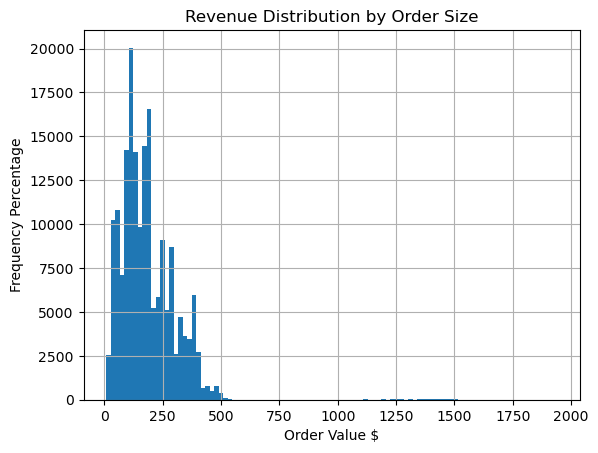

In [116]:
#order value distribution histogram
df["Order Item Total"].hist(bins=100)

plt.title("Revenue Distribution by Order Size")
plt.xlabel("Order Value $")
plt.ylabel("Frequency Percentage")
plt.show()

In [98]:
#Most orders are in the 0 to 500$ segment, meaning that an order value segmentation can be a useful slicer/insight in the analysis

In [28]:
#product price describtion
desc = df["Product Price"].describe()
desc.loc["mode"] = df["Product Price"].mode().round(2)
print(desc)

count                                          180519.0
mean                                          141.23255
std                                          139.732492
min                                                9.99
25%                                                50.0
50%                                           59.990002
75%                                          199.990005
max                                          1999.98999
mode     0    59.99
Name: Product Price, dtype: float64
Name: Product Price, dtype: object


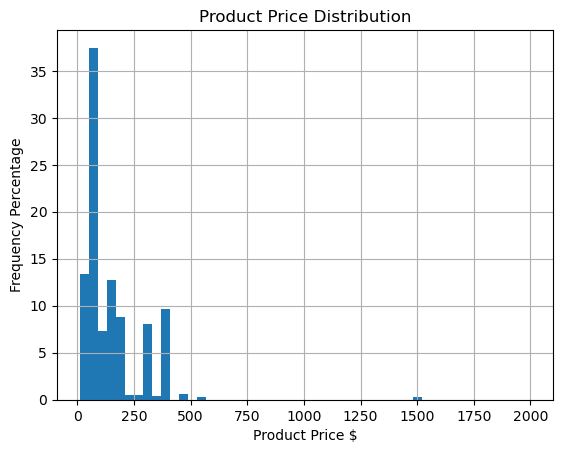

In [117]:
#product price distribution histogram
df["Product Price"].hist(bins=50, weights=np.ones_like(df["Product Price"]) / len(df["Product Price"]) * 100)

plt.title("Product Price Distribution")
plt.xlabel("Product Price $")
plt.ylabel("Frequency Percentage")
plt.show()

In [ ]:
#Most items are in the 0 to 250$ segment, some in the 250 to 500$, meaning that a price segmentation can be a useful slicer in the analysis

In [65]:
#customer revenue distribution
customer_rev = (
    df.groupby("Customer Id")["Order Item Total"]
      .sum()
)
customer_rev.describe()

count    20652.000000
mean      1600.542436
std       1508.417956
min          8.470000
25%        254.940002
50%       1294.504997
75%       2621.140007
max       9436.610088
Name: Order Item Total, dtype: float64

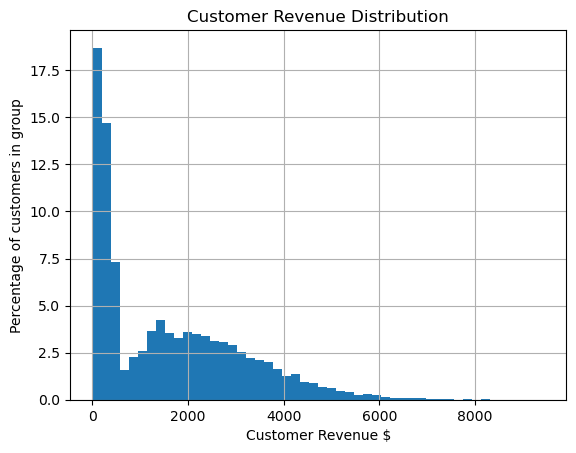

In [124]:
#customer revenue distribution histogram 
customer_rev.hist(bins=50, weights=np.ones_like(customer_rev) / len(customer_rev) * 100)

plt.title("Customer Revenue Distribution")
plt.xlabel("Customer Revenue $")
plt.ylabel("Percentage of customers in group")
plt.show()

In [ ]:
#The distribution is right-skewed meaning a big section of customers are bringing in a revenue of less than 500$(LTV)

In [77]:
#Customer orders distribution
orders_per_customer = (
    df.groupby("Customer Id")["Order Id"]
      .nunique()
)
orders_per_customer.describe().round(0)

count    20652.0
mean         3.0
std          2.0
min          1.0
25%          1.0
50%          3.0
75%          5.0
max         15.0
Name: Order Id, dtype: float64

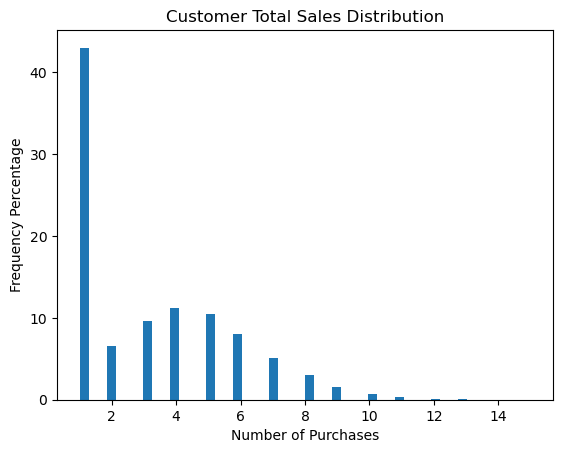

In [102]:
#customer orders distribution histogram 
plt.hist(orders_per_customer, bins=50, weights=np.ones_like(orders_per_customer) / len(orders_per_customer) * 100)

plt.title("Customer Total Sales Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Frequency Percentage")
plt.show()

In [94]:
# More than 40% of customers are one timers, but a good chunk of them comeback so calculating customer related metrics like churn rate and retention are relevant! 